# Exploratory Data Analysis (EDA) - ENSANUT 2018

This notebook performs an exploratory analysis of the integrated ENSANUT 2018 dataset, focusing on the distribution of data by states and regions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setting plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
DATA_PATH = "../../data/ensanut_integrated.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.copy() # Avoid Fragmentation

print(f"Dataset shape: {df.shape}")

Dataset shape: (43070, 826)


### Data Cleaning and Numeric Conversion

We convert key columns to numeric, handling potential strings or empty spaces.

In [3]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.strip().replace('', np.nan), errors='coerce')

df['EDAD'] = clean_numeric(df['EDAD'])
df['ENT'] = clean_numeric(df['ENT'])
df['REGION'] = clean_numeric(df['REGION'])

if 'PESO1_1' in df.columns:
    df['PESO1_1'] = clean_numeric(df['PESO1_1'])
if 'TALLA4_1' in df.columns:
    df['TALLA4_1'] = clean_numeric(df['TALLA4_1'])

### Analytic Population Filter

We restrict our analysis to the adult population (age >= 18) and exclude individuals who are currently pregnant to avoid bias in anthropometric outcomes.

In [ ]:
# 1. Filter adults >= 18 years old
initial_shape = df.shape[0]
df = df[df['EDAD'] >= 18].copy()

# 2. Exclude pregnant individuals (P8_9 == 1 means Currently pregnant)
if 'P8_9' in df.columns:
    df['P8_9'] = clean_numeric(df['P8_9'])
    df = df[~((df['SEXO'] == 2) & (df['P8_9'] == 1))].copy()

final_shape = df.shape[0]
print(f"Original records: {initial_shape}")
print(f"Records after age (>=18) and pregnancy exclusion: {final_shape}")
print(f"Excluded: {initial_shape - final_shape} records")

### Mapping Codes to Labels

We map the state (`ENT`) and region (`REGION`) codes to their respective names.

In [4]:
state_mapping = {
    1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur', 4: 'Campeche',
    5: 'Coahuila', 6: 'Colima', 7: 'Chiapas', 8: 'Chihuahua',
    9: 'Ciudad de México', 10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero',
    13: 'Hidalgo', 14: 'Jalisco', 15: 'Estado de México', 16: 'Michoacán',
    17: 'Morelos', 18: 'Nayarit', 19: 'Nuevo León', 20: 'Oaxaca',
    21: 'Puebla', 22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
    25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco', 28: 'Tamaulipas',
    29: 'Tlaxcala', 30: 'Veracruz', 31: 'Yucatán', 32: 'Zacatecas'
}

region_mapping = {
    1: 'Norte', 
    2: 'Centro',
    3: 'Ciudad de México',
    4: 'Sur'
}

df['Estado'] = df['ENT'].map(state_mapping)
df['Region_Name'] = df['REGION'].map(region_mapping)
df = df.copy() # Avoid Fragmentation

## 1. Distribution by State

Analyzing the representation of each Mexican state in the dataset.

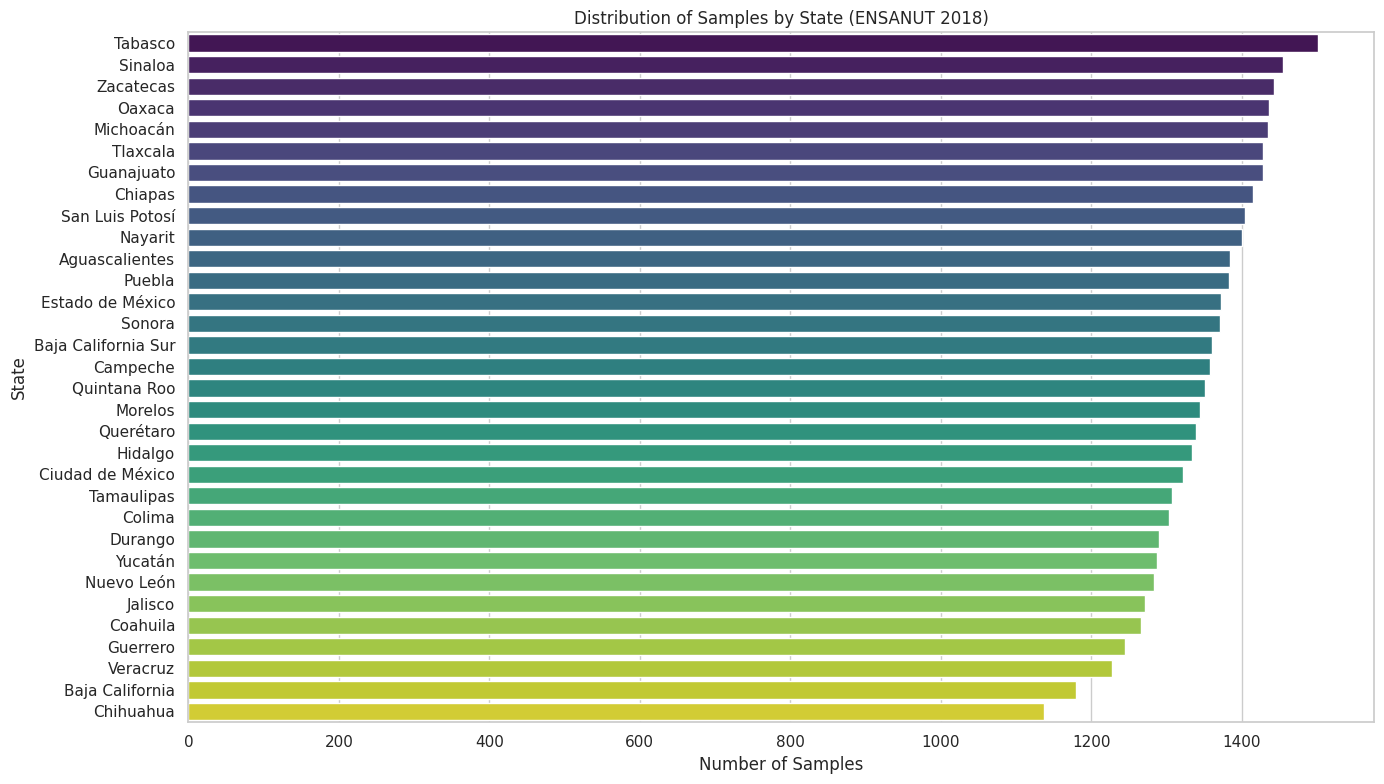

In [5]:
state_counts = df['Estado'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=state_counts.values, y=state_counts.index, hue=state_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Samples by State (ENSANUT 2018)')
plt.xlabel('Number of Samples')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## 2. Distribution by Region

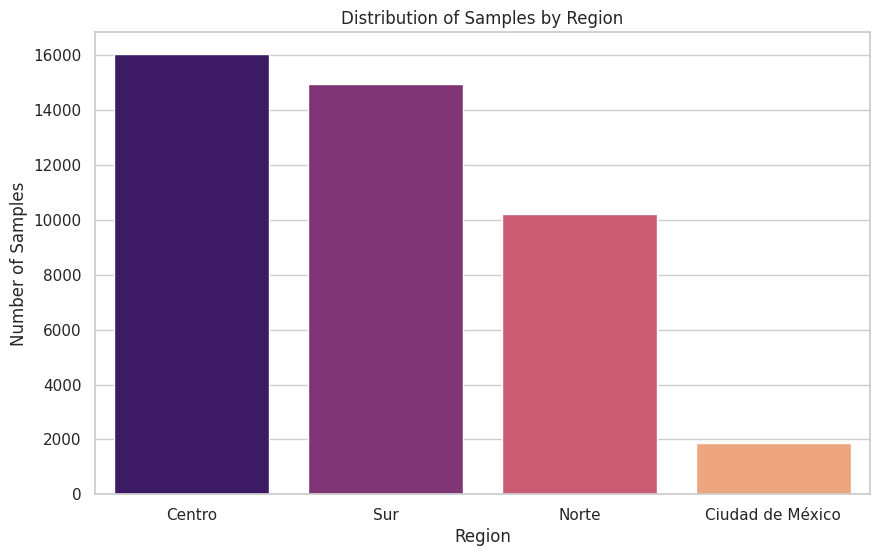

In [6]:
region_counts = df['Region_Name'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, hue=region_counts.index, palette='magma', legend=False)
plt.title('Distribution of Samples by Region')
plt.xlabel('Region')
plt.ylabel('Number of Samples')
plt.show()

## 3. Demographics by Region (Age Distribution)

Understanding the age structure of the population across regions.

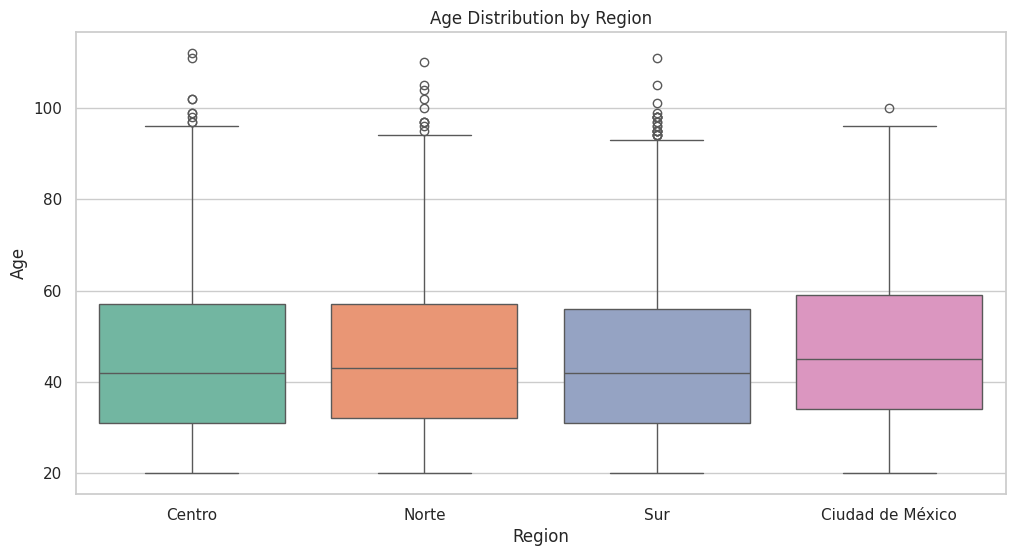

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region_Name', y='EDAD', hue='Region_Name', palette='Set2', legend=False)
plt.title('Age Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Age')
plt.show()

## 4. Anthropometric Indicators by Region (BMI)

If height and weight data are available, we calculate the Body Mass Index (BMI).

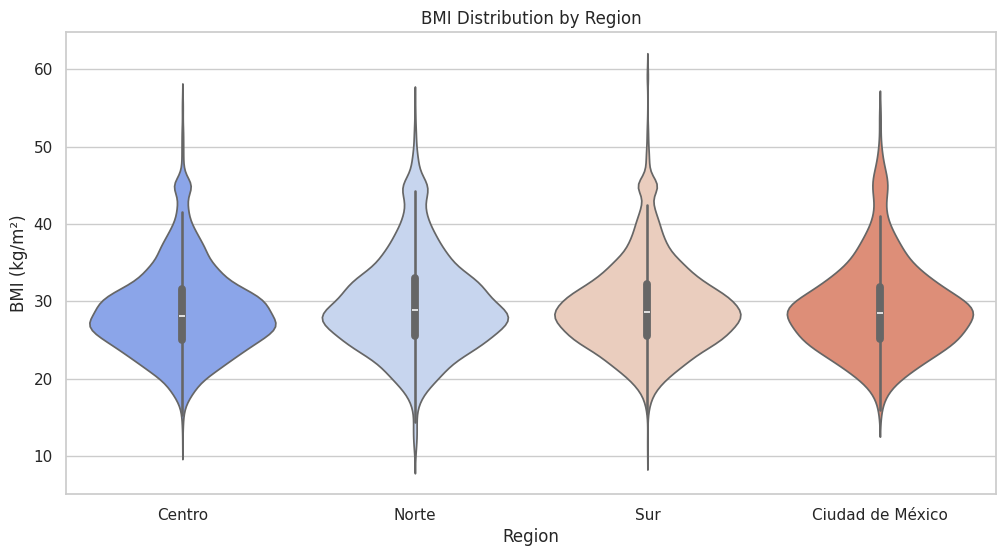

In [8]:
if 'PESO1_1' in df.columns and 'TALLA4_1' in df.columns:
    # Ensuring height is in meters (if it was in cm)
    # If TALLA4_1 > 10 it's likely cm, if < 3 it might be meters already
    # Standard ENSANUT talla is cm.
    df['BMI'] = df['PESO1_1'] / ((df['TALLA4_1'] / 100) ** 2)
    
    # Filtering reasonable BMI values for visualization
    df_filtered = df[(df['BMI'] > 10) & (df['BMI'] < 60)].copy()
    
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df_filtered, x='Region_Name', y='BMI', hue='Region_Name', palette='coolwarm', legend=False)
    plt.title('BMI Distribution by Region')
    plt.xlabel('Region')
    plt.ylabel('BMI (kg/m²)')
    plt.show()

## 5. Summary Statistics Table

Numerical breakdown of the main variables by region.

In [9]:
metrics = ['EDAD']
if 'BMI' in df.columns:
    metrics.append('BMI')

summary_region = df.groupby('Region_Name')[metrics].agg(['mean', 'std']).round(2)
summary_region['Sample_Size'] = df['Region_Name'].value_counts()

summary_region

EDAD           BMI       Sample_Size
                   mean    std   mean   std            
Region_Name                                            
Centro            44.90  16.93  28.97  6.48       16038
Ciudad de México  47.01  16.81  29.26  6.27        1866
Norte             45.31  16.55  29.77  6.69       10198
Sur               44.75  16.54  29.39  5.95       14968

### EDA Results Interpretation

1. **Distribution by State and Region**:
   - A significant representation of states such as **Estado de México, Veracruz, and Jalisco** is observed, which is consistent with their population density.
   - Regionally, the **Central and Southern** zones contribute the largest number of samples to the integrated dataset, reflecting the survey's broad coverage.

2. **Anthropometric Profiles**:
   - **Age**: The age distribution shows a diverse adult population, with a similar median across regions, although Mexico City shows a slight trend toward older ages compared to the Southern region.
   - **Body Mass Index (BMI)**: A notable prevalence of overweight and obesity (BMI > 25 kg/m²) is observed across all regions. The **Northern** region shows slightly higher average BMI values.

3. **Data Consistency**:
   - The cleaning process allowed for the recovery of critical numerical values for the analysis of sarcopenic obesity. Consistency in BMI means suggests that metabolic health challenges are a national phenomenon, albeit with regional variations in data dispersion.

In [1]:
import session_info

session_info.show(std_lib=True, dependencies=True)